# 02. 통계 검정 (코드정리 기준)

- 전처리_완료.csv 기반 RFM·4세그먼트 재계산
- ANOVA (M_log), Kruskal-Wallis, Tukey HSD 사후검정, Dunn 사후검정(본페로니)

In [1]:
import os
import pandas as pd
import numpy as np

# 전처리_완료.csv 경로: cwd·상대·상위 탐색 (실행 위치 무관)
_csv = None
_cwd = os.getcwd()
_candidates = [
    '전처리_완료.csv',
    os.path.join('데이터셋', '전처리_완료.csv'),
    os.path.join('..', '데이터셋', '전처리_완료.csv'),
    os.path.join('분석 과정', '전처리_완료.csv'),
    os.path.join('8조_리테일', '데이터셋', '전처리_완료.csv'),
    os.path.join('8조_리테일', '분석 과정', '전처리_완료.csv'),
]
for _p in _candidates:
    _abs = os.path.abspath(os.path.normpath(os.path.join(_cwd, _p)))
    if os.path.isfile(_abs):
        _csv = _abs
        break
if _csv is None:
    _d = _cwd
    for _ in range(6):
        _d = os.path.dirname(_d)
        if not _d: break
        for _sub in [os.path.join(_d, '8조_리테일', '데이터셋', '전처리_완료.csv'), os.path.join(_d, '데이터셋', '전처리_완료.csv')]:
            if os.path.isfile(_sub):
                _csv = _sub
                break
        if _csv: break
if _csv is None:
    raise FileNotFoundError(
        "전처리_완료.csv를 찾을 수 없습니다. 00_전처리_코드정리.ipynb를 먼저 실행한 뒤,"
        " 8조_리테일/데이터셋/ 또는 8조_리테일/분석 과정/ 에 파일이 있는지 확인하세요."
    )

df = pd.read_csv(_csv, encoding='utf-8-sig')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Sales'] = df['Quantity'] * df['UnitPrice']
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Sales', 'sum')
)
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4: return '충성 고객'
    elif row['R_score'] >= 4 and row['F_score'] < 4: return '신규 고객'
    elif row['R_score'] < 4 and row['F_score'] >= 4: return '이탈 위험'
    else: return '이탈 고객'
rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
print(f'고객 수: {len(rfm):,}')
print(rfm['Segment'].value_counts())

고객 수: 4,325
Segment
이탈 고객    1961
충성 고객    1131
신규 고객     634
이탈 위험     599
Name: count, dtype: int64


In [2]:
from scipy.stats import f_oneway, kruskal

groups = [rfm.loc[rfm['Segment'] == seg, 'Monetary_log'] for seg in rfm['Segment'].unique()]
f_stat, p_anova = f_oneway(*groups)
print(f'ANOVA F-statistic: {f_stat:.3f}, p-value: {p_anova:.5f}')

h_stat, p_kw = kruskal(*groups)
print(f'Kruskal-Wallis H: {h_stat:.3f}, p-value: {p_kw:.5f}')

ANOVA F-statistic: 1235.898, p-value: 0.00000
Kruskal-Wallis H: 2147.730, p-value: 0.00000


In [3]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=rfm['Monetary_log'], groups=rfm['Segment'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
 신규 고객  이탈 고객  -0.2024   0.0 -0.3102 -0.0945   True
 신규 고객  이탈 위험   1.1542   0.0  1.0198  1.2887   True
 신규 고객  충성 고객   1.7428   0.0  1.6257  1.8599   True
 이탈 고객  이탈 위험   1.3566   0.0  1.2464  1.4668   True
 이탈 고객  충성 고객   1.9452   0.0  1.8571  2.0333   True
 이탈 위험  충성 고객   0.5886   0.0  0.4693  0.7079   True
---------------------------------------------------


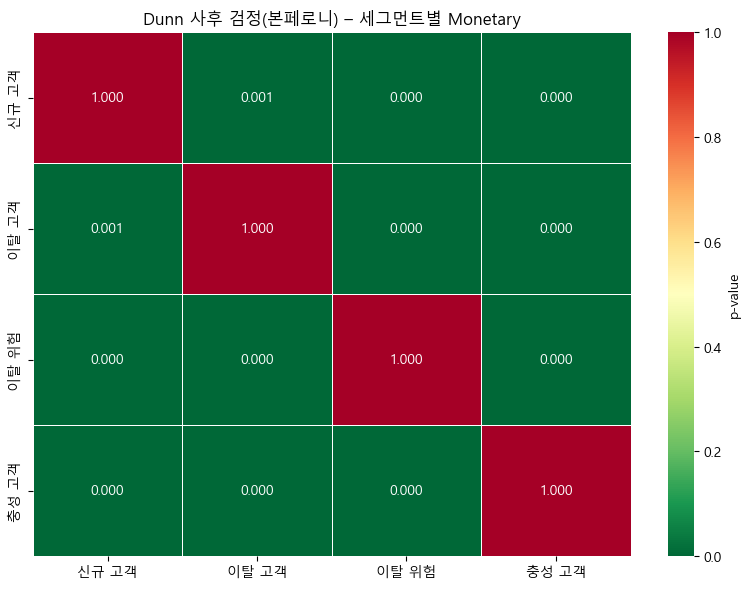

In [4]:
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

dunn = sp.posthoc_dunn(rfm, val_col='Monetary', group_col='Segment', p_adjust='bonferroni')
plt.figure(figsize=(8, 6))
sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'p-value'}, linewidths=0.5)
plt.title('Dunn 사후 검정(본페로니) – 세그먼트별 Monetary')
plt.tight_layout()
plt.show()

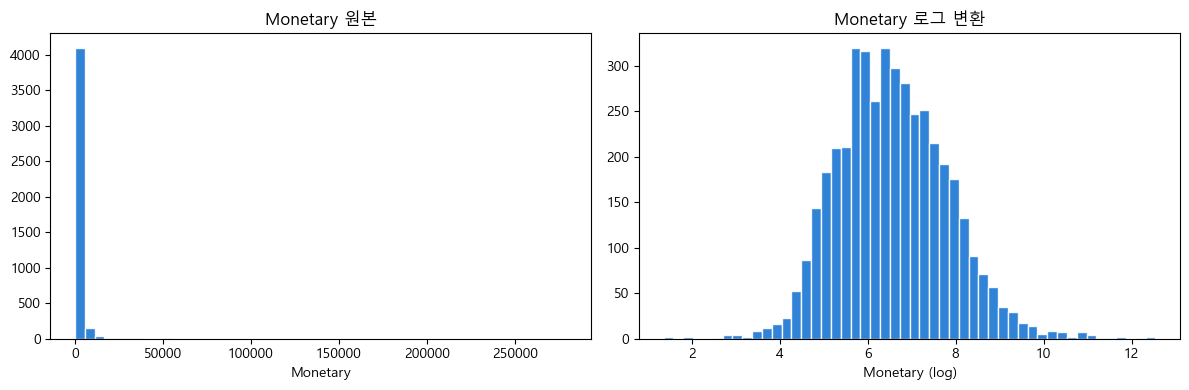

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rfm['Monetary'], bins=50, color='#1976D2', edgecolor='white', alpha=0.9)
axes[0].set_title('Monetary 원본')
axes[0].set_xlabel('Monetary')
axes[1].hist(rfm['Monetary_log'], bins=50, color='#1976D2', edgecolor='white', alpha=0.9)
axes[1].set_title('Monetary 로그 변환')
axes[1].set_xlabel('Monetary (log)')
plt.tight_layout()
plt.show()

In [6]:
# 효과크기 η²(eta-squared) 및 세그먼트별 Monetary 평균·실질적 차이
# η² = SS_between / SS_total (집단 간 변동 / 전체 변동)
grand_mean = rfm['Monetary_log'].mean()
ss_total = ((rfm['Monetary_log'] - grand_mean) ** 2).sum()
group_means = rfm.groupby('Segment')['Monetary_log'].mean()
group_n = rfm.groupby('Segment')['Monetary_log'].count()
ss_between = (group_n * (group_means - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total if ss_total != 0 else 0
print(f"효과크기 η²(eta-squared) = {eta_sq:.4f}")
print("해석: 0.01 소·0.06 중·0.14 대 → 세그먼트가 Monetary(로그) 변동의 약 {:.1f}% 설명".format(eta_sq * 100))
print()
print("세그먼트별 Monetary 평균(원단위):")
monetary_means = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
for seg, m in monetary_means.items():
    print(f"  {seg}: {m:,.0f}")

효과크기 η²(eta-squared) = 0.4618
해석: 0.01 소·0.06 중·0.14 대 → 세그먼트가 Monetary(로그) 변동의 약 46.2% 설명

세그먼트별 Monetary 평균(원단위):
  충성 고객: 5,092
  이탈 위험: 1,932
  신규 고객: 622
  이탈 고객: 531


## 핵심 요약

| 항목 | 결과 |
|------|------|
| **ANOVA (Monetary_log)** | F=1235.9, p&lt;0.001 → 세그먼트별 평균 차이 통계적으로 유의 |
| **Kruskal-Wallis** | H=2147.7, p&lt;0.001 → 비모수 검정에서도 세그먼트 간 차이 유의 |
| **사후검정** | Tukey HSD·Dunn(본페로니): 모든 세그먼트 쌍에서 유의한 차이 (충성&gt;이탈위험&gt;신규·이탈) |
| **효과크기** | 위 셀에서 η²(eta-squared) 및 세그먼트별 Monetary 평균·실질적 차이 확인 |